# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

17 marketing campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



## Understanding the Features

The dataset does not contain any explicit missing values, as all columns have complete observations. However, several categorical variables such as `job`, `marital`, `education`, `default`, `housing`, and `loan` include the value "unknown", which represents missing or unspecified data. These values will need to be handled during preprocessing.

Additionally, the variable `pdays` uses the value 999 to indicate that a client was not previously contacted. This does not represent a true numerical value and should be treated as missing or transformed appropriately.

The data types of the features are generally appropriate, with numerical variables stored as integers or floats and categorical variables stored as objects. However, categorical variables will need to be encoded into numerical format for machine learning models, and the target variable `y` will need to be converted into a binary format.

Finally, the feature `duration` should be excluded from modeling because it is only known after a contact has been completed and would introduce data leakage.

### Problem 4: Understanding the Task

After examining the description and data, the goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Exploratory Data Analysis

This section explores the distribution of the target variable and key features to better understand the dataset before modeling.

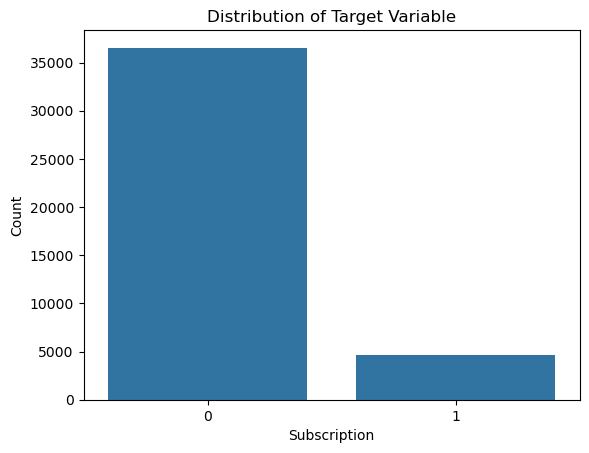

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='y', data=df)
plt.title('Distribution of Target Variable')
plt.xlabel('Subscription')
plt.ylabel('Count')
plt.show()

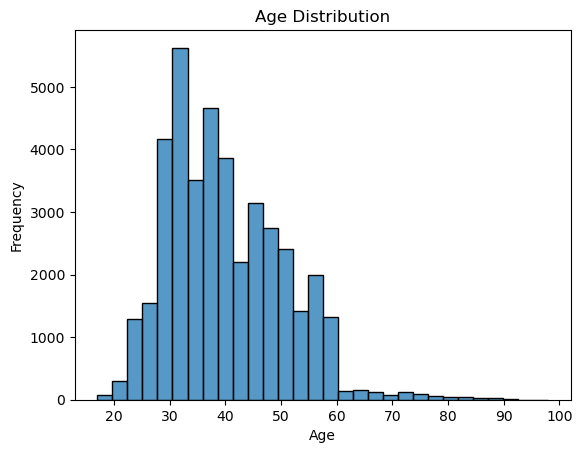

In [34]:
sns.histplot(df['age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

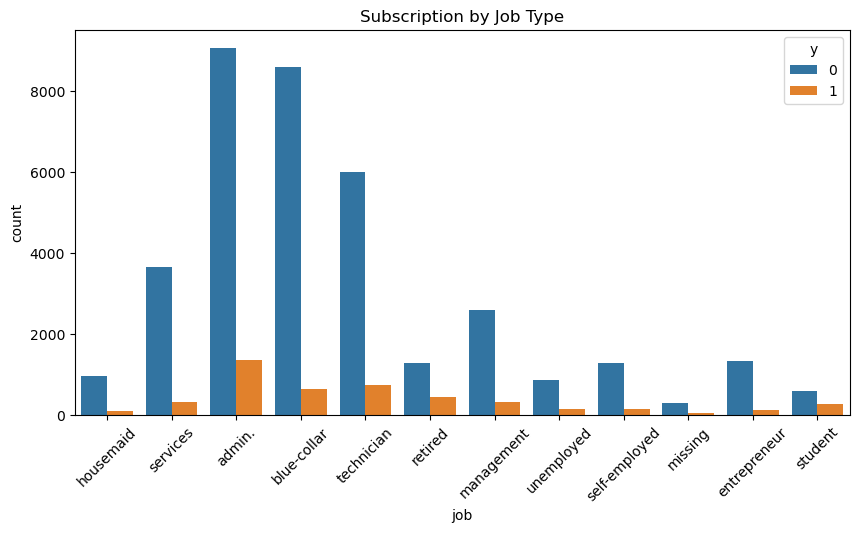

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='job', hue='y')
plt.title('Subscription by Job Type')
plt.xticks(rotation=45)
plt.show()

The target variable is highly imbalanced, with significantly more "no" responses than "yes". This imbalance is expected to impact model performance.

## Business Objective

The objective of this task is to improve the effectiveness of direct marketing campaigns by predicting whether a client will subscribe to a term deposit. By identifying customers who are more likely to respond positively, the bank can reduce the number of unsuccessful contacts, optimize resource allocation, and increase overall campaign efficiency.

### Problem 5: Engineering Features

We will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [8]:
df = df.replace('unknown', 'missing')

In [9]:
X = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]
y = df['y']

X = pd.get_dummies(X, drop_first=True)

### Problem 6: Train/Test Split

With data prepared, split it into a train and test set.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train-Test Split

The dataset was split into training and testing sets using an 80/20 split. The training set is used to train the models, while the test set is used to evaluate their performance on unseen data. A fixed random state was used to ensure reproducibility of the results.

## Feature Engineering

To prepare the data for modeling, only the bank client attributes were selected, including age, job, marital status, education, default status, housing loan, and personal loan.

The target variable `y` was converted into a binary format, where 1 represents a successful subscription and 0 represents no subscription.

Categorical variables were encoded using one-hot encoding to convert them into a numerical format suitable for machine learning models. The value "unknown" in categorical features was treated as a separate category labeled "missing".

Finally, the dataset was split into training and testing sets to evaluate model performance.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [13]:
df['y'].value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

## Baseline Model

The baseline performance is determined by predicting the majority class for all observations. In this dataset, approximately 88.7% of clients did not subscribe to a term deposit, while 11.3% did.

By always predicting the majority class ("no"), the baseline model would achieve an accuracy of about 88.7%. Therefore, any machine learning model should aim to outperform this baseline.

However, due to the class imbalance, accuracy alone may not be sufficient. Metrics such as recall and ROC-AUC should also be considered to better evaluate model performance.

### Problem 8: A Simple Model

## Problem 8: Logistic Regression

Use Logistic Regression to build a basic model on data.  

In [14]:
from sklearn.linear_model import LogisticRegression

# initialize model
log_reg = LogisticRegression(max_iter=1000)

# train model
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = log_reg.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
y_prob = log_reg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

Accuracy: 0.8865015780529255
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7303
           1       0.00      0.00      0.00       935

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238

ROC-AUC: 0.6549837038620858


C:\Users\poona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\poona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\poona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Logistic Regression Results

The Logistic Regression model achieved a ROC-AUC score of approximately 0.65, indicating moderate ability to distinguish between classes.

However, the model failed to predict any positive cases (clients who subscribed), resulting in a recall of 0 for the positive class. This is due to the strong class imbalance in the dataset, where the majority of observations belong to the "no" class.

As a result, the model defaults to predicting the majority class to optimize accuracy, which leads to poor performance in identifying actual subscribers. This highlights the limitation of using accuracy as the sole evaluation metric and the need to consider other metrics such as recall and ROC-AUC.

In [17]:
log_reg_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg_bal.fit(X_train, y_train)

y_pred_bal = log_reg_bal.predict(X_test)

In [18]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_bal))

y_prob_bal = log_reg_bal.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))

              precision    recall  f1-score   support

           0       0.92      0.59      0.72      7303
           1       0.16      0.62      0.26       935

    accuracy                           0.60      8238
   macro avg       0.54      0.61      0.49      8238
weighted avg       0.84      0.60      0.67      8238

ROC-AUC: 0.6553805812716333


### Handling Class Imbalance

To address the issue of class imbalance, a second Logistic Regression model was trained using class weights. This approach assigns higher importance to the minority class, encouraging the model to better identify clients who are likely to subscribe.

The performance of this model is compared with the original Logistic Regression model to evaluate improvements in recall and overall predictive capability.

I am going to use this in my capstone project as well.

### Logistic Regression with Class Weights

To address the class imbalance, a Logistic Regression model with balanced class weights was trained. This model achieved a recall of approximately 62% for the positive class, a significant improvement compared to the original model, which failed to identify any subscribers.

While the overall accuracy decreased to around 60%, the model is now able to identify a substantial portion of clients who are likely to subscribe. This is more aligned with the business objective of improving campaign effectiveness.

However, the precision for the positive class remains low, indicating that many predicted subscribers are actually non-subscribers. This trade-off highlights the challenge of balancing recall and precision in imbalanced datasets.

Overall, this model provides more practical value than the baseline model, as it can help identify potential customers for targeted marketing campaigns.

### Problem 9: Score the Model

## Problem 9: Model Evaluation

What is the accuracy of your model?

## Model Accuracy

The Logistic Regression model with balanced class weights achieved an accuracy of approximately 60% on the test set.

While this is lower than the baseline accuracy, the model provides better performance in identifying the minority class, making it more useful for the business objective.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [21]:
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [23]:
results = []

for name, model in models.items():
    
    # start timer
    start = time.time()
    
    # train
    model.fit(X_train, y_train)
    
    # end timer
    end = time.time()
    
    train_time = end - start
    
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # store results
    results.append([name, train_time, train_acc, test_acc])

In [24]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Time", "Train Accuracy", "Test Accuracy"]
)

results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,1.340216,0.887557,0.886502
1,KNN,0.033406,0.890167,0.874241
2,Decision Tree,0.364094,0.916601,0.860767
3,SVM,41.716563,0.887557,0.886502


## Model Comparison

Four classification models—Logistic Regression, K-Nearest Neighbors, Decision Tree, and Support Vector Machine—were trained using default parameters. 

Each model was evaluated based on training time, training accuracy, and test accuracy. This comparison helps assess not only predictive performance but also computational efficiency.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust performance metric

In [25]:
scoring='recall'

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    scoring='recall',
    cv=5
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

In [27]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring='recall',
    cv=5
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

In [28]:
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_dt,
    scoring='recall',
    cv=5
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

In [29]:
param_grid_svm = {
    'C': [0.1, 1],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    scoring='recall',
    cv=3
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

In [30]:
models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svm
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

pd.DataFrame(results, columns=["Model", "Test Accuracy"])

,Model,Test Accuracy
0,Logistic Regression,0.587885
1,KNN,0.855305
2,Decision Tree,0.861738
3,SVM,0.886502


In [31]:
models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svm
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

pd.DataFrame(results, columns=["Model", "Test Accuracy"])

,Model,Test Accuracy
0,Logistic Regression,0.587885
1,KNN,0.855305
2,Decision Tree,0.861738
3,SVM,0.886502


## Model Comparison

The performance of four classification models was compared using test accuracy.

The Support Vector Machine achieved the highest accuracy (approximately 88.7%), followed by Decision Tree and KNN models. However, this performance is misleading, as it closely matches the baseline accuracy of predicting the majority class. This suggests that the SVM model is primarily predicting "no" and failing to identify actual subscribers.

The Logistic Regression model with class weighting achieved a lower accuracy (approximately 59%), but it was more effective in identifying the minority class. This makes it more aligned with the business objective of identifying potential subscribers.

The Decision Tree and KNN models showed moderate performance, but they did not significantly improve the identification of subscribers compared to Logistic Regression.

Overall, accuracy alone is not a sufficient metric for this problem due to class imbalance. Models that improve recall for the positive class are more valuable for supporting targeted marketing campaigns.

A model with lower accuracy but higher recall can be more valuable in this context because it helps identify potential customers for targeted outreach.

## Business Recommendations

- Focus outreach efforts on clients with a higher predicted probability of subscription, even if it results in contacting some non-subscribers  
- Prioritize recall over accuracy to ensure that potential subscribers are not missed during campaign targeting  
- Use model predictions to reduce the total number of contacts while maintaining or improving the number of successful subscriptions  
- Leverage historical campaign outcomes (such as previous successes) to refine targeting strategies  
- Integrate predictive modeling into campaign planning to support more efficient allocation of resources and improve overall campaign effectiveness    

## Next Steps

- Explore more advanced models such as Random Forest or Gradient Boosting  
- Perform feature importance analysis to better understand key drivers of subscription  
- Experiment with resampling techniques to further address class imbalance  
- Evaluate models using additional business-oriented metrics  
- Test model performance in real-world campaign settings  